### Custom Models in BoTorch
In this tutorial, we illustrate how to create a custom surrogate model using the [`Model`](https://github.com/meta-pytorch/botorch/blob/main/botorch/models/model.py) and [`Posterior`](https://github.com/meta-pytorch/botorch/blob/main/botorch/posteriors/posterior.py) interface. We will cover creating surrogate models from: 
- PyTorch distributions
- Posterior samples (using NumPyro)
- Ensemble of ML predictions

This tutorial differs from the [Modular BoTorch tutorial](https://ax.dev/docs/tutorials/modular_botorch/) Ax tutorial by focusing more on authoring a new model that is compatible with the BoTorch and less on integrating a custom model with Ax's modular BoTorch model API.

In [1]:
# Install dependencies if we are running in colab
import sys
if 'google.colab' in sys.modules:
    %pip install botorch numpyro jax jaxlib

In [2]:
import torch

# Set the seed for reproducibility
torch.manual_seed(1)
# Double precision is highly recommended for BoTorch.
# See https://github.com/meta-pytorch/botorch/discussions/1444
torch.set_default_dtype(torch.float64)

train_X = torch.rand(20, 2) * 2
Y = 1 - (train_X - 0.5).norm(dim=-1, keepdim=True)
Y += 0.1 * torch.rand_like(Y)
bounds = torch.stack([torch.zeros(2), 2 * torch.ones(2)])

I0324 085427.037 _utils_internal.py:284] NCCL_DEBUG env var is set to None
I0324 085427.038 _utils_internal.py:303] NCCL_DEBUG is forced to WARN from None


Code to plot our training data.

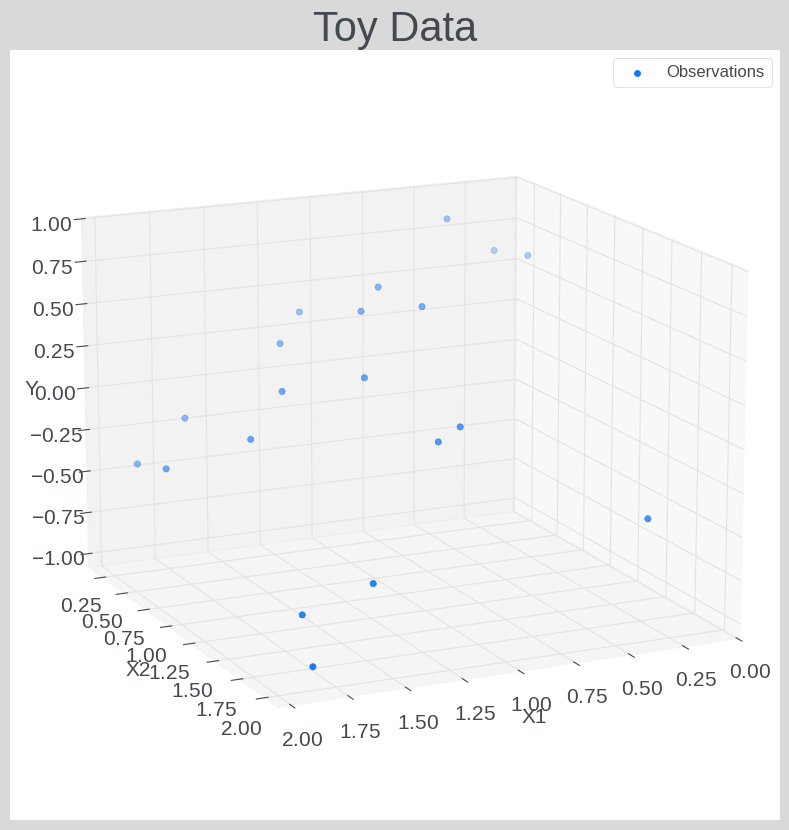

In [3]:
from matplotlib import pyplot as plt
from matplotlib.axes import Axes
from torch import Tensor
from mpl_toolkits.mplot3d import Axes3D

# Needed for older versions of matplotlib.
assert Axes3D


def plot_toy_data(x: Tensor, y: Tensor) -> Axes:
    ax = plt.figure().add_subplot(projection="3d")
    ax.scatter(
        x[:, 0].detach().numpy().squeeze(),
        x[:, 1].detach().numpy().squeeze(),
        zs=y.detach().numpy().squeeze(),
        label="Observations",
    )
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")
    ax.set_zlabel("Y")
    ax.set_title("Toy Data")
    ax.view_init(elev=15.0, azim=65)
    ax.legend()
    return ax


plot_toy_data(x=train_X, y=Y)
plt.show()

### Probabilistic Linear Regression (w/ Torch Distributions)
BoTorch's `Model` class only requires you to define a `posterior()` method that returns a `Posterior` object, the only requirement of which is to implement an `rsample()` function for drawing posterior samples. Specifically, we can utilize the subclass [`TorchPosterior`](https://github.com/meta-pytorch/botorch/blob/main/botorch/posteriors/torch.py) that directly wraps a [torch distribution](https://pytorch.org/docs/stable/distributions.html).

In [4]:
from typing import Optional, Union
from torch import Tensor, distributions, nn
from botorch.acquisition.objective import PosteriorTransform
from botorch.models.model import Model
from botorch.posteriors.posterior import Posterior
from botorch.posteriors.torch import TorchPosterior


class ProbabilisticRegressionModel(Model):
    _num_outputs: int

    def __init__(self, train_X: Tensor, train_Y: Tensor):
        super(ProbabilisticRegressionModel, self).__init__()
        self._num_outputs = train_Y.shape[-1]
        # Linear layer that will compute the regression output.
        self.linear = nn.Linear(train_X.shape[-1], self.num_outputs)

    @property
    def num_outputs(self) -> int:
        return self._num_outputs

    def forward(self, x: Tensor) -> distributions.Distribution:
        # For now, let's suppose we have known variance 1.
        return distributions.StudentT(df=3., loc=self.linear(x), scale=1)

    def posterior(
        self,
        X: Tensor,
        output_indices: Optional[list[int]] = None,
        observation_noise: Union[bool, Tensor] = False,
        posterior_transform: Optional[PosteriorTransform] = None,
    ) -> Posterior:
        if output_indices:
            X = X[..., output_indices]
        # TorchPosterior directly wraps our torch.distributions.Distribution output.
        posterior = TorchPosterior(distribution=self(X))
        if posterior_transform is not None:
            posterior = posterior_transform(posterior)
        return posterior

In [6]:
def fit_prob_reg(
    epochs: int,
    model: ProbabilisticRegressionModel,
    optimizer: torch.optim.Optimizer,
    train_X: Tensor,
    train_Y: Tensor,
) -> None:
    """Optimization loop for linear regression."""
    train_X = train_X.requires_grad_()
    for epoch in range(epochs):
        optimizer.zero_grad()
        outputs = model(train_X)
        loss = -outputs.log_prob(train_Y).mean()
        loss.backward()
        optimizer.step()
        if epoch % 10 == 0:
            print("epoch {}, loss {}".format(epoch, loss.item()))

In [7]:
prob_regression_model = ProbabilisticRegressionModel(train_X, Y)
optimizer = torch.optim.Adam(prob_regression_model.parameters(), lr=0.1)
fit_prob_reg(50, prob_regression_model, optimizer, train_X, Y)

I0324 085504.952 structured_logging.py:1049] TritonTraceHandler: disabled because /logs does not exist
W0324 085504.953 triton_util.py:163] ===========[FB_TRITON]=========== Triton Version: 3.5.0+fb


epoch 0, loss 1.4067664345474094
epoch 10, loss 1.1349407118418473
epoch 20, loss 1.0426907808272752
epoch 30, loss 1.0281791195725944
epoch 40, loss 1.0313219974336634


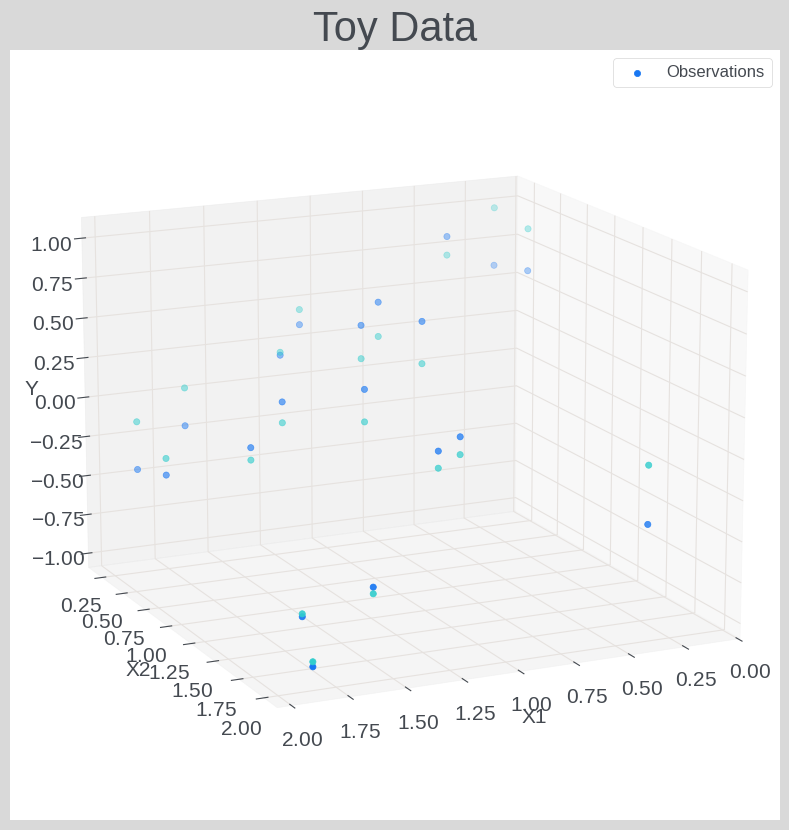

In [8]:
ax = plot_toy_data(x=train_X, y=Y)
ax.scatter(
    train_X[:, 0].detach().numpy().squeeze(),
    train_X[:, 1].detach().numpy().squeeze(),
    zs=prob_regression_model(train_X).mean.detach().squeeze().numpy(),
)
plt.show()

Finally, since our custom model is based off `Model` and `Posterior`, we can use both analytic and MC based acquisition functions for optimization.

In [9]:
from botorch.acquisition.analytic import LogExpectedImprovement
from botorch.optim.optimize import optimize_acqf

candidate, acq_val = optimize_acqf(
    LogExpectedImprovement(model=prob_regression_model, best_f=Y.max()),
    bounds=bounds,
    q=1,
    num_restarts=5,
    raw_samples=10,
)
candidate, acq_val

(tensor([[0., 0.]]), tensor(-0.1333))

Before using `qLogExpectedImprovement` we need to register an appropriate sampler for the `TorchPosterior`. We can use the following code to create a `MCSampler` for that is specific to `torch.distributions.StudentT`.

In [10]:
from botorch.sampling.base import MCSampler
from botorch.sampling.get_sampler import GetSampler
from botorch.sampling.stochastic_samplers import ForkedRNGSampler


@GetSampler.register(distributions.StudentT)
def _get_sampler_torch(
    posterior: TorchPosterior,
    sample_shape: torch.Size,
    *,
    seed: Optional[int] = None,
) -> MCSampler:
    # Use `ForkedRNGSampler` to ensure determinism in acquisition function evaluations.
    return ForkedRNGSampler(sample_shape=sample_shape, seed=seed)

In [11]:
from botorch.acquisition.logei import qLogExpectedImprovement

optimize_acqf(
    qLogExpectedImprovement(model=prob_regression_model, best_f=Y.max()),
    bounds=bounds,
    q=1,
    num_restarts=5,
    raw_samples=10,
)

(tensor([[0., 0.]]), tensor(-0.1924))

#### Supported PyTorch Distributions
Although we chose the `StudentT` distribution in the above example, any distribution supporting the `rsample` method will work with BoTorch's automatic differentiation. We can use the `has_rsample` attribute to see a complete listing of compatible distributions.

In [12]:
print(
    [
        j.__name__
        for j in [getattr(distributions, i) for i in distributions.__all__]
        if hasattr(j, "has_rsample") and j.has_rsample
    ]
)

['Beta', 'Cauchy', 'Chi2', 'ContinuousBernoulli', 'Dirichlet', 'Exponential', 'FisherSnedecor', 'Gamma', 'GeneralizedPareto', 'Gumbel', 'HalfCauchy', 'HalfNormal', 'Independent', 'InverseGamma', 'Kumaraswamy', 'Laplace', 'LogNormal', 'LogisticNormal', 'LowRankMultivariateNormal', 'MultivariateNormal', 'Normal', 'OneHotCategoricalStraightThrough', 'Pareto', 'RelaxedBernoulli', 'RelaxedOneHotCategorical', 'StudentT', 'Uniform', 'Weibull', 'Wishart', 'TransformedDistribution']


### Bayesian Linear Regression
In the previous section, we directly parameterized a "posterior" with a linear layer. In this section, we will follow Chapter 14.2 of [Bayesian Data Analysis](https://stat.columbia.edu/~gelman/book/) to implement a *proper* posterior analytically. This implementation also uses `TorchPosterior` and the `StudentT` distribution like before.

In [13]:
from typing import Optional, Union
from torch import Tensor, distributions, nn
from botorch.acquisition.objective import PosteriorTransform
from botorch.models.model import Model
from botorch.posteriors.posterior import Posterior
from botorch.posteriors.torch import TorchPosterior


def add_intercept(x: Tensor) -> Tensor:
    """Adds an intercept column to the design matrix (i.e. tensor)."""
    return torch.concat([torch.ones_like(x)[..., 0:1], x], dim=-1)


class BayesianRegressionModel(Model):
    _num_outputs: int
    df: int
    s_squared: Tensor
    beta: Tensor
    L: Tensor
    add_intercept: bool

    def __init__(self, intercept: bool = True) -> None:
        super(BayesianRegressionModel, self).__init__()
        self.add_intercept = intercept

    @property
    def num_outputs(self) -> int:
        return self._num_outputs

    def forward(self, x: Tensor) -> Tensor:
        return x @ self.beta

    def fit(self, x: Tensor, y: Tensor) -> None:
        self._num_outputs = y.shape[-1]
        x = add_intercept(x) if self.add_intercept else x
        self.df = 3.
        # Rather than V = torch.linalg.inv(x.T @ x) as in BDA
        # instead use L = torch.linalg.cholesky(x.T @ x) for stability.
        # To use L, we can simply replace operations like:
        # x = V @ b
        # with a call to `torch.cholesky_solve`:
        # x = torch.cholesky_solve(b, L)
        self.L = torch.linalg.cholesky(x.T @ x)
        # Least squares estimate
        # self.beta = torch.cholesky_solve(x.T, self.L) @ y
        self.beta = torch.cholesky_solve(x.T, self.L) @ y
        # Model's residuals from the labels.
        r: Tensor = y - self(x)
        # Sample variance
        self.s_squared = (1 / self.df) * r.T @ r

    def posterior(
        self,
        X: Tensor,
        output_indices: Optional[list[int]] = None,
        observation_noise: Union[bool, Tensor] = False,
        posterior_transform: Optional[PosteriorTransform] = None,
    ) -> Posterior:
        if output_indices:
            X = X[..., output_indices]
        if self.add_intercept:
            X = add_intercept(X)

        n, q, d = X.shape # only evaluating shape, after shape feature changes
        assert q == 1, "Only one query point is supported"
        loc = self(X)
        # Full covariance matrix of all test points.
        cov = self.s_squared * (
            torch.eye(n, n) + X.view(-1,d) @ torch.cholesky_solve(X.view(-1,d).T, self.L)
        )
        # The batch semantics of BoTorch evaluate each data point in their own batch.
        # So, we extract the diagonal representing Var[\tilde y_i | y_i] of each test point.
        scale = torch.diag(cov).reshape(n, q, self.num_outputs)
        # Form the posterior predictive dist according to Sec 14.2, Pg 357 of BDA.
        posterior_predictive_dist = distributions.StudentT(
            df=self.df, loc=loc, scale=scale
        )
        posterior = TorchPosterior(distribution=posterior_predictive_dist)
        if posterior_transform is not None:
            posterior = posterior_transform(posterior)
        return posterior

In [14]:
bayesian_regression_model = BayesianRegressionModel(intercept=True)
bayesian_regression_model.fit(train_X, Y)

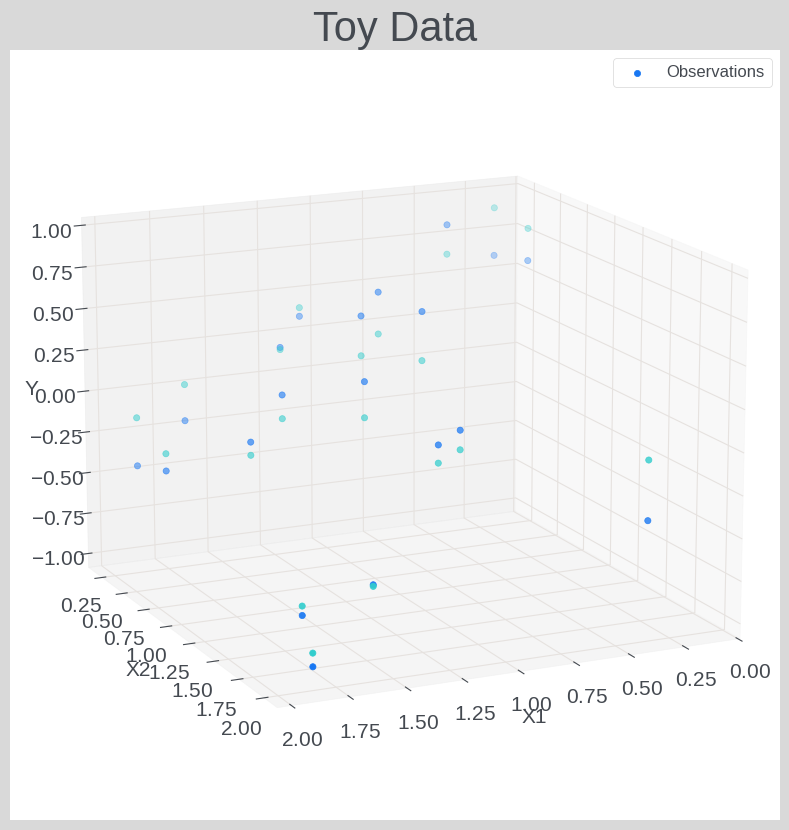

In [15]:
ax = plot_toy_data(x=train_X, y=Y)
ax.scatter(
    train_X[:, 0].detach().numpy().squeeze(),
    train_X[:, 1].detach().numpy().squeeze(),
    zs=bayesian_regression_model(add_intercept(train_X)).detach().squeeze().numpy(),
)
plt.show()

In [16]:
optimize_acqf(
    LogExpectedImprovement(model=bayesian_regression_model, best_f=Y.max()),
    bounds=bounds,
    q=1,
    num_restarts=5,
    raw_samples=10,
)

(tensor([[0., 0.]]), tensor(-0.9797))

In [17]:
optimize_acqf(
    qLogExpectedImprovement(model=bayesian_regression_model, best_f=Y.max()),
    bounds=bounds,
    q=1,
    num_restarts=5,
    raw_samples=10,
)

(tensor([[0., 0.]]), tensor(-1.0001))

### Bayesian Linear Regression w/ `EnsemblePosterior`
The `EnsembleModel` class provides a default implementation for `posterior()`. Then the MC acquisition function will be optimized using samples from the posterior predictive distribution (`EnsemblePosterior` also implements `mean` and `variance` properties, so some other analytic acquisition functions will also work). We use [NumPyro](https://num.pyro.ai/) with [Stochastic Variational Inference](https://num.pyro.ai/en/latest/svi.html) (SVI) to fit a Bayesian linear regression model.

First, we define a NumPyro model capable of sampling from a posterior predictive distribution for new observations at test points. NumPyro models are plain Python functions that use `numpyro.sample` to define random variables. Later, when we perform posterior predictive inference, we will use NumPyro's [`Predictive`](https://num.pyro.ai/en/latest/utilities.html#numpyro.infer.util.Predictive) class.

In [18]:
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as numpyro_dist
from numpyro.infer import SVI, Trace_ELBO, Predictive
from numpyro.infer.autoguide import AutoDiagonalNormal

numpyro.set_host_device_count(1)

OBS_NAME = "y"


def numpyro_regression_model(x, y=None):
    """NumPyro Bayesian linear regression model."""
    in_features = x.shape[-1]
    out_features = 1
    # Priors on weights and bias.
    weight = numpyro.sample(
        "weight",
        numpyro_dist.Normal(jnp.zeros((out_features, in_features)), 1.0).to_event(2),
    )
    bias = numpyro.sample(
        "bias",
        numpyro_dist.Normal(jnp.zeros(out_features), 10.0).to_event(1),
    )
    # Prior for the noise level.
    sigma = numpyro.sample("sigma", numpyro_dist.Uniform(0.0, 10.0))
    # Linear layer on the inputs.
    mean = (x @ weight.T + bias).squeeze(-1)
    with numpyro.plate("data", x.shape[0]):
        # Observations will be t distributed.
        numpyro.sample(
            OBS_NAME,
            numpyro_dist.StudentT(df=3.0, loc=mean, scale=sigma),
            obs=y,
        )

In [19]:
from botorch.utils.jax_utils import torch_to_jax

def fit_svi(
    num_steps: int,
    model,
    guide,
    train_X: Tensor,
    train_Y: Tensor,
    lr: float = 0.1,
):
    """Fit a NumPyro model using SVI."""
    optimizer = numpyro.optim.Adam(step_size=lr)
    svi = SVI(model, guide, optimizer, loss=Trace_ELBO())
    rng_key = jax.random.PRNGKey(0)
    # Convert PyTorch tensors to JAX arrays for NumPyro.
    jax_X = torch_to_jax(train_X)
    jax_Y = torch_to_jax(train_Y.squeeze())
    svi_result = svi.run(rng_key, num_steps, jax_X, y=jax_Y, progress_bar=False)
    # Print some losses.
    losses = svi_result.losses
    for epoch in range(0, num_steps, num_steps // 10):
        print(f"epoch {epoch}, loss {losses[epoch]:.4f}")
    return svi_result

Now, we incorporate our NumPyro model into the `Model` and `Posterior` interface like before. `EnsemblePosterior` expects a `(b) x s x q x m` tensor where `m` is the output size of the model and `s` is the ensemble size.

In [20]:
from botorch.models.ensemble import EnsembleModel
from botorch.utils.jax_utils import jax_to_torch


class EnsembleBayesianRegressionModel(EnsembleModel):
    num_samples: int
    _num_outputs: int

    def __init__(self, train_X: Tensor, train_Y: Tensor, num_samples: int = 100):
        super(EnsembleBayesianRegressionModel, self).__init__()
        self._num_outputs = train_Y.shape[-1]
        self.num_samples = num_samples
        self.guide = AutoDiagonalNormal(numpyro_regression_model)
        self.svi_result = None

    def forward(self, X: Tensor) -> Tensor:
        # Use NumPyro's Predictive to draw posterior predictive samples.
        predictive = Predictive(
            numpyro_regression_model,
            guide=self.guide,
            params=self.svi_result.params,
            num_samples=self.num_samples,
            return_sites=(OBS_NAME,),
        )
        jax_X = torch_to_jax(X.squeeze())
        rng_key = jax.random.PRNGKey(42)
        jax_samples = predictive(rng_key, jax_X)[OBS_NAME]
        # Convert JAX samples back to PyTorch.
        samples = jax_to_torch(jax_samples, device=X.device, dtype=X.dtype)
        # `EnsemblePosterior` expects a `(b) x s x q x m` tensor where `m` is the
        # output size of the model and `s` is the ensemble size.
        samples = samples.T.reshape(X.shape[0], -1, 1, self.num_outputs)
        return samples

In [21]:
ensemble_bayesian_regression_model = EnsembleBayesianRegressionModel(
    train_X=train_X, train_Y=Y
)
svi_result = fit_svi(
    num_steps=100,
    model=numpyro_regression_model,
    guide=ensemble_bayesian_regression_model.guide,
    train_X=train_X,
    train_Y=Y,
)
ensemble_bayesian_regression_model.svi_result = svi_result

INFO:2026-03-24 08:55:44,769:jax._src.xla_bridge:925: Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
I0324 085544.769 xla_bridge.py:925] Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:2026-03-24 08:55:44,774:jax._src.xla_bridge:925: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
I0324 085544.774 xla_bridge.py:925] Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


epoch 0, loss 74.5642
epoch 10, loss 67.7099
epoch 20, loss 53.6854
epoch 30, loss 47.2587
epoch 40, loss 43.0267
epoch 50, loss 21.8751
epoch 60, loss 31.8207
epoch 70, loss 27.8315
epoch 80, loss 21.1610
epoch 90, loss 59.0145


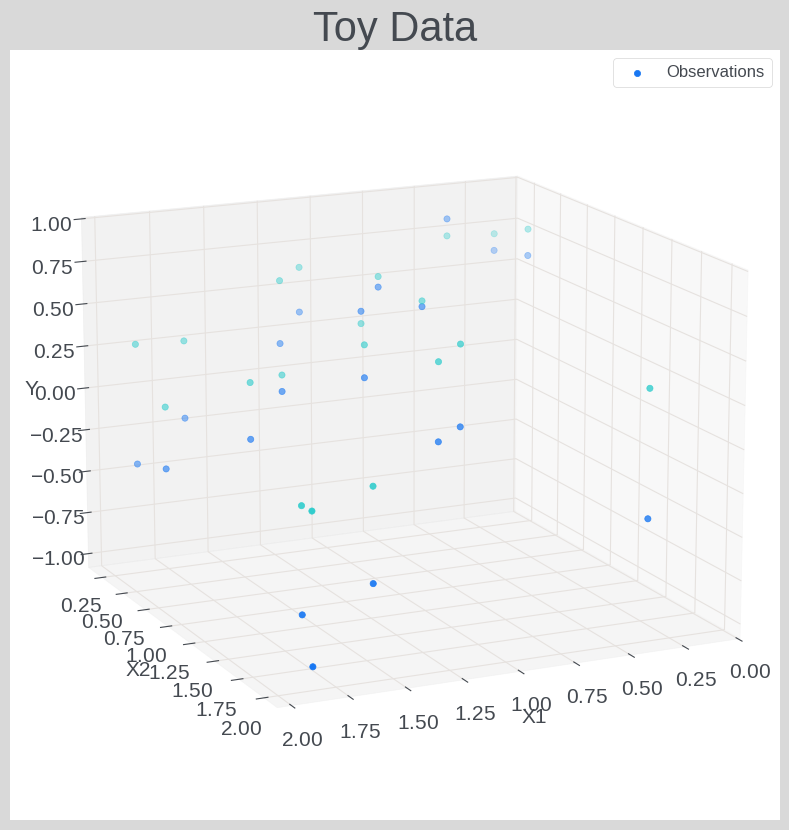

In [22]:
ax = plot_toy_data(x=train_X, y=Y)
ax.scatter(
    train_X[:, 0].detach().numpy().squeeze(),
    train_X[:, 1].detach().numpy().squeeze(),
    zs=ensemble_bayesian_regression_model(train_X)
    .detach()
    .squeeze()
    .mean(dim=-1)
    .numpy(),
)
plt.show()

Since the NumPyro model's predictions are converted from JAX arrays to PyTorch tensors (via `jax_to_torch`), gradients do not flow through the model's `forward` method w.r.t. the input `X`. We therefore use gradient-free optimization by passing `options={"with_grad": False}` to `optimize_acqf`.

In [ ]:
optimize_acqf(
    LogExpectedImprovement(model=ensemble_bayesian_regression_model, best_f=Y.max()),
    bounds=bounds,
    q=1,
    num_restarts=5,
    raw_samples=10,
    options={"with_grad": False},
)

In [ ]:
optimize_acqf(
    qLogExpectedImprovement(model=ensemble_bayesian_regression_model, best_f=Y.max()),
    bounds=bounds,
    q=1,
    num_restarts=5,
    raw_samples=10,
    options={"with_grad": False},
)

### Random Forest w/ Ensemble Posterior
Finally, we move away from linear models to any ML technique that ensembles many models. Specifically, we can use the [RandomForestRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html) from sklearn which is an ensemble method of individual decision trees. These decision trees can be accessed through the object's `estimators_` attribute.

In [25]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from botorch.models.ensemble import EnsembleModel


class EnsembleRandomForestModel(EnsembleModel):
    model: RandomForestRegressor
    num_samples: int
    _num_outputs: int

    def __init__(self, num_samples: int = 100):
        super(EnsembleRandomForestModel, self).__init__()
        self._num_outputs = 1
        self.model = RandomForestRegressor(n_estimators=num_samples)

    def fit(self, X: Tensor, y: Tensor) -> None:
        self.model = self.model.fit(
            X=X.detach().numpy(), y=y.detach().numpy().squeeze()
        )

    def forward(self, X: Tensor) -> Tensor:
        x = X.detach().numpy().squeeze()
        # Create the ensemble from predictions from each decision tree.
        y = torch.from_numpy(np.array([i.predict(x) for i in self.model.estimators_]))
        # `EnsemblePosterior` expects a `(b) x s x q x m` tensor where `m` is the
        # output size of the model and `s` is the ensemble size.
        samples = y.transpose(0, 1).reshape(X.shape[0], -1, 1, self.num_outputs)
        return samples

In [26]:
ensemble_random_forest_model = EnsembleRandomForestModel(num_samples=300)
ensemble_random_forest_model.fit(X=train_X, y=Y)

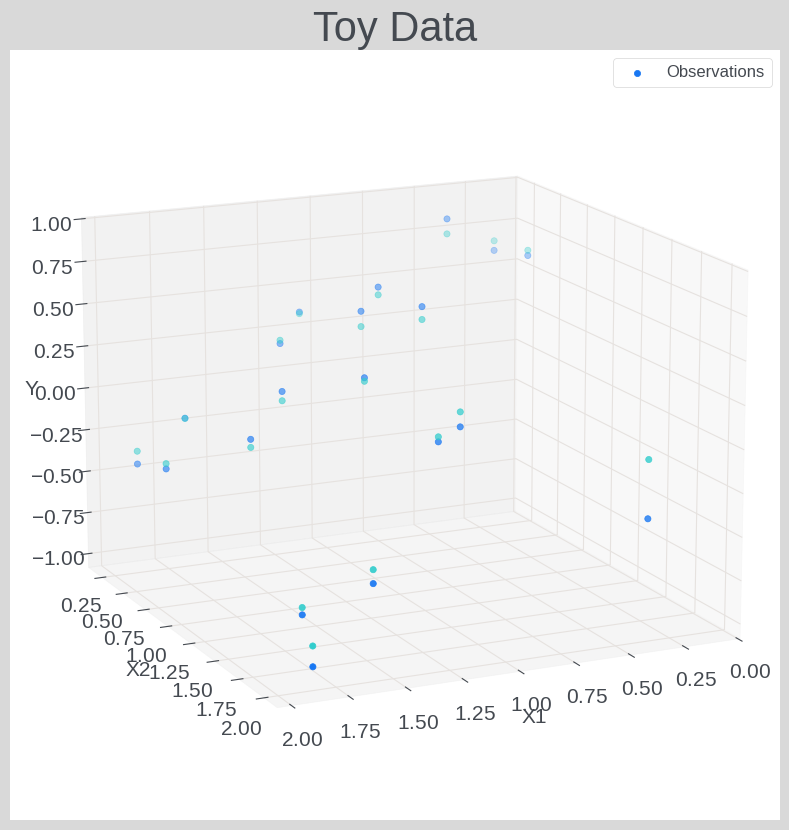

In [27]:
ax = plot_toy_data(x=train_X, y=Y)
ax.scatter(
    train_X[:, 0].detach().numpy().squeeze(),
    train_X[:, 1].detach().numpy().squeeze(),
    zs=ensemble_random_forest_model(train_X).detach().squeeze().mean(dim=-1).numpy(),
)
plt.show()

In order to use gradient-based optimization of the acquisition function (via the standard `optimize_acqf()` method) we will need to have the samples drawn from the posterior be differentiable w.r.t. to the input to the `posterior()` method (this is not the case for Random Forest models). Instead, we will perform the acquisition function optimization with gradient-free methods.

In [28]:
optimize_acqf(
    LogExpectedImprovement(model=ensemble_random_forest_model, best_f=Y.max()),
    bounds=bounds,
    q=1,
    num_restarts=5,
    raw_samples=10,
    options={"with_grad": False},
)

(tensor([[0.5872, 0.9863]]), tensor(-4.0751))

In [29]:
optimize_acqf(
    qLogExpectedImprovement(model=ensemble_random_forest_model, best_f=Y.max()),
    bounds=bounds,
    q=1,
    num_restarts=5,
    raw_samples=10,
    options={"with_grad": False},
)

(tensor([[0.5572, 0.2554]]), tensor(-14.7641))

#### CMA-ES
We can also move the optimization loop out of BoTorch entirely and follow the [CMA-ES tutorial](https://botorch.org/docs/tutorials/optimize_with_cmaes) to optimize with an evolution strategy.

In [30]:
import cma
import numpy as np

x0 = np.random.rand(2)

es = cma.CMAEvolutionStrategy(
    x0=x0,
    sigma0=0.2,
    inopts={"bounds": [0, 2], "popsize": 50},
)

log_expected_improvement_ensemble_random_forest_model = LogExpectedImprovement(
    model=ensemble_random_forest_model, best_f=Y.max()
)

with torch.no_grad():
    while not es.stop():
        xs = es.ask()
        y = (
            -log_expected_improvement_ensemble_random_forest_model(
                torch.from_numpy(np.array(xs)).unsqueeze(-2)
            )
            .view(-1)
            .double()
            .numpy()
        )
        es.tell(xs, y)

torch.from_numpy(es.best.x)

(25_w,50)-aCMA-ES (mu_w=14.0,w_1=14%) in dimension 2 (seed=487860, Tue Mar 24 08:56:39 2026)


tensor([0.3440, 0.3741])